TOPOMAP

Extracting BDF parameters from ../data/sub-060_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 617471  =      0.000 ...   602.999 secs...
Effective window size : 4.000 (s)


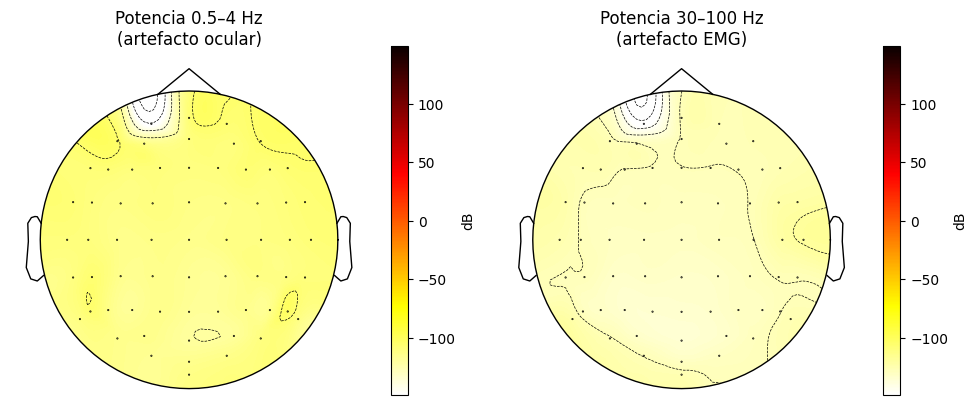

In [73]:
import mne
import numpy as np
import matplotlib.pyplot as plt


raw = mne.io.read_raw_bdf(input_fname='../data/sub-060_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]
raw_eeg = raw.copy().pick(eeg_channels)

montage = mne.channels.make_standard_montage('biosemi64')
raw_eeg.set_montage(montage)

spectrum = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=48, n_fft=4096)
freqs = spectrum.freqs
psds = spectrum.get_data()

mask_ocular = (freqs >= 0.5) & (freqs <= 4)
power_ocular_db = 10 * np.log10(psds[:, mask_ocular].mean(axis=1))

mask_emg = (freqs >= 30) & (freqs <= 100) ####
power_emg_db = 10 * np.log10(psds[:, mask_emg].mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1, _ = mne.viz.plot_topomap(power_ocular_db, raw_eeg.info, axes=axes[0],
                               show=False, cmap='hot_r')
axes[0].set_title('Potencia 0.5–4 Hz\n(artefacto ocular)')
plt.colorbar(im1, ax=axes[0], label='dB')

im2, _ = mne.viz.plot_topomap(power_emg_db, raw_eeg.info, axes=axes[1],
                               show=False, cmap='hot_r')
axes[1].set_title('Potencia 30–100 Hz\n(artefacto EMG)')
plt.colorbar(im2, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

Extracting BDF parameters from ../data/sub-070_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 616447  =      0.000 ...   601.999 secs...
Effective window size : 4.000 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.03 - 0.08 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Blackman window with 0.0017 passband ripple and 74 dB stopband attenuation
- Lower passband edge: 0.03
- Lower transition bandwidth: 0.03 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 0.08 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.08 Hz)
- Filter length: 170667 samples (166.667 s)

Effective window size : 4.000 (s)


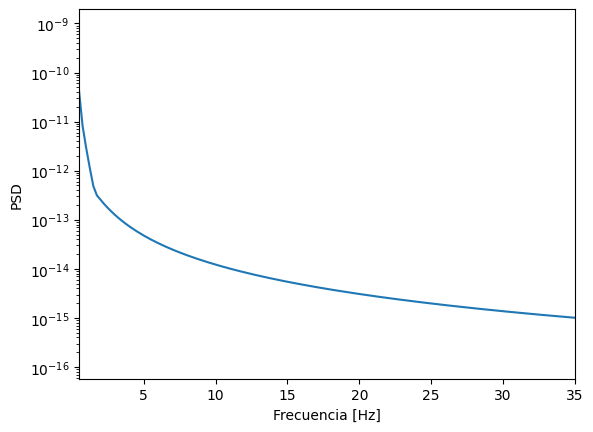

Setting up band-stop filter from 15 - 17 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 15.00
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 14.75 Hz)
- Upper passband edge: 17.00 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 17.25 Hz)
- Filter length: 6759 samples (6.601 s)

Effective window size : 4.000 (s)


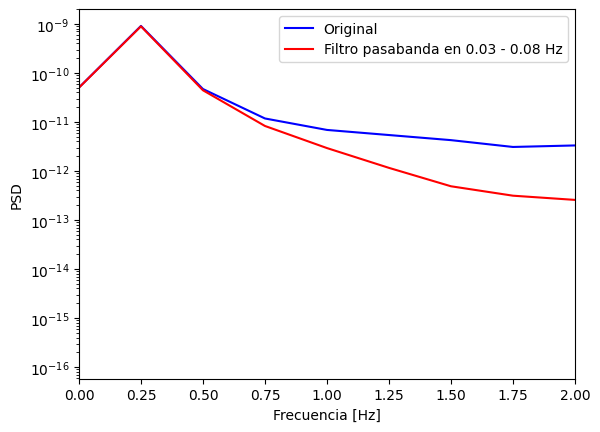

2.987504413698225e-13
2.1909757287839016e-14
8.574144570862085e-15
7.817093225923108e-15
[1.07279991e-11 1.44870232e-10 1.26305381e-11 2.44904538e-12
 9.14899678e-13 4.09087920e-13 9.85482632e-14 4.92071081e-14
 3.70486072e-14 3.07101917e-14 2.56088519e-14 2.16136377e-14
 1.84472631e-14 1.59089495e-14 1.38463994e-14 1.21516904e-14
 1.07460885e-14 9.56652219e-15 8.56907352e-15 7.71810352e-15
 6.98634864e-15 6.35324779e-15 5.80181085e-15 5.31848651e-15
 4.89301534e-15 4.51601238e-15 4.18101352e-15 3.88157969e-15
 3.61307076e-15 3.37150223e-15 3.15315644e-15 2.95532169e-15
 2.77543969e-15 2.61150290e-15 2.46161573e-15 2.32415732e-15
 2.19799433e-15 2.08171522e-15 1.97444846e-15 1.87523494e-15
 1.78330545e-15 1.69794192e-15 1.61858224e-15 1.54462255e-15
 1.47563358e-15 1.41114833e-15 1.35079766e-15 1.29422529e-15
 1.24113946e-15 1.19124578e-15 1.14429852e-15 1.10007091e-15
 1.05835566e-15 1.01896908e-15 9.81737693e-16 9.46509809e-16
 9.13141692e-16 8.81508545e-16 8.51490520e-16 8.22977231e

In [75]:
import os
import gdown
from pathlib import Path
import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy
from mne.viz import plot_filter, plot_ideal_filter
import glob, os
import re
import pandas as pd
import openpyxl
from scipy.stats import spearmanr

from specparam import SpectralModel

raw = mne.io.read_raw_bdf(input_fname='../data/sub-070_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]
#Me quedo solo con los EEG
raw_eeg=raw.copy().pick(eeg_channels)

#aplicamos pasabajos con fc=100 Hz
psdss, freqss = mne.time_frequency.psd_array_welch(
    raw_eeg.get_data()[30], 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")
eeg_filtrado=raw_eeg.filter(l_freq=0.03, h_freq=0.08,method='fir', fir_window='blackman')

psds, freqs = mne.time_frequency.psd_array_welch(
    eeg_filtrado.get_data()[30], 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

a= np.arange(49, 512, 32) 
b= np.arange(49,512,50)
freqs_notch = (np.concatenate((a,[49.7]), axis=None))
plt.plot(freqs,psds)
plt.semilogy()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.xlim(0.5,35)
plt.show()

#Aplico filtro nothc para sacar ruido de linea >50Hz
filtrado = mne.filter.notch_filter(
    eeg_filtrado.get_data()[20],
    Fs=1024,
    freqs= [16],
    notch_widths = 1,
    method = 'fir'
)

psds_f, freqs_f = mne.time_frequency.psd_array_welch(
    filtrado, 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

plt.plot(freqss, psdss, color = "blue",label='Original')
plt.plot(freqs,psds,color="red", label='Filtro pasabanda en 0.03 - 0.08 Hz')

plt.semilogy()

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.xlim(0,2)
plt.legend()
plt.show()

#ANALISIS PSD POR
bandas = [[1,4],[4, 8], [8,13],[13,30]]

for i in range(len(bandas)):
    mask = (freqs_f >= bandas[i][0]) & (freqs_f <= bandas[i][1])
    band_power = np.trapezoid(psds_f[mask],freqs_f[mask])
    print(band_power)


print(psds_f)
print(freqs_f)



ANALISIS PSD

In [69]:



regiones = {
"frontal": ["Fz", "F1", "F2", "F3", "F4","F5","F6","F7","F8"],
"central": ["Cz", "C1", "C2", "C3", "C4","C5","C6"],
"parietal": ["Pz", "P1", "P2", "P3", "P4","P5","P6","P7","P8"],
"occipital": ["Oz", "O1", "O2"],
}



bandas = {
"delta": [1,4],
"theta": [4,8],
"alfa": [8,13],
"beta": [13,30],
}


resultados_PSD = []
resultados_aperiodico = []
resultado_asimetria = []
for archivo in glob.glob("../data/*.bdf"):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    if numero_sujeto < 60: 
        grupo = "CTR"
    else:
        grupo = "EXP"

    psd_F3 = None
    psd_F4 = None

    print("sujeto ",numero_sujeto)
    raw = mne.io.read_raw_bdf(input_fname=archivo, preload=True)
    for region, electrodos in regiones.items():
        eeg_channels = electrodos #ME QUEDO SOLO CON LOS CANALES QUE QUIERO DE CADA REGION 
        raw_eeg=raw.copy().pick(eeg_channels) 
        #ACA APLICAR PREPROCESAMIENTO   
       #aplicamos pasabajos con fc=100 Hz
        eeg_filtrado_100=raw_eeg.filter(l_freq=None, h_freq=100)

        freqs_notch= np.arange(49, 100, 32) 

        #Aplico filtro nothc para sacar ruido de linea >50Hz
        for canal in eeg_channels:
            #region = eeg_channels[p]
            filtrado_notch = mne.filter.notch_filter(
                eeg_filtrado_100.get_data(picks=canal)[0],
                Fs=1024,
                freqs=freqs_notch,
                notch_widths = 2,
                method = 'fir'
            )

            psds_f, freqs_f = mne.time_frequency.psd_array_welch(
                filtrado_notch, 
                sfreq=1024, 
                n_fft=4096,
                fmax=100,
                n_per_seg=4096, 
                output="power")
            
            #me guardo los psds para calcular la asimetria despues
            if canal in ["F3"]:
                psd_F3 = psds_f

            if canal in ["F4"]:
                psd_F4 = psds_f

            for banda, rango in bandas.items():
                
                mask = (freqs_f >= rango[0]) & (freqs_f <= rango[1])
                potencia = np.trapezoid(psds_f[mask],freqs_f[mask])

                resultados_PSD.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "banda": banda,
                "potencia": potencia,
                })
                #analisis aperiodico
                sm = SpectralModel(verbose=False)
                freq_mask = (freqs_f >= 0.5) & (freqs_f <= 50)
                freqs_crop = freqs_f[freq_mask]
                psds_crop  = psds_f[freq_mask]

                # Initialize model object and fit power spectrum
                fm = SpectralModel(min_peak_height=0.1)
                fm.fit(freqs_crop, psds_crop)

                resultados_aperiodico.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "aperiodico": fm.results.params.aperiodic.params[1],
                })

    #ASIMETRIA AFLFA (F3,F4)
    mask = (freqs_f >= 8) & (freqs_f <= 13)
    potencia_F4 = np.trapezoid(psd_F4[mask],freqs_f[mask])
    potencia_F3 = np.trapezoid(psd_F3[mask],freqs_f[mask])
    asimetria = np.log(potencia_F4) - np.log(potencia_F3)
    resultado_asimetria.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "asimetria": asimetria,
                })


       

df = pd.DataFrame(resultados_PSD)
resumen = df.groupby(["sujeto", "grupo", "region", "banda"])["potencia"].mean().reset_index()
resumen.to_csv("resumen_psd.csv", index=False)

df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])



sujeto  31
Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter

In [70]:
import pandas as pd
import numpy as np
from openpyxl import Workbook

df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])


orden_regiones = ["frontal", "central", "parietal", "occipital"]
orden_bandas = ["delta", "theta", "alfa", "beta"]

wb = Workbook()
wb.remove(wb.active)

for banda in orden_bandas:
    sub = df[df["banda"] == banda]
    ctr_suj = sorted(sub[sub["grupo"] == "CTR"]["sujeto"].unique())
    exp_suj = sorted(sub[sub["grupo"] == "EXP"]["sujeto"].unique())

    ws = wb.create_sheet(banda)
    ws.cell(2, 1, "region")
    col = 2
    for g, sujs in [("CTR", ctr_suj), ("EXP", exp_suj)]:
        for s in sujs:
            ws.cell(1, col, g)            # fila 1: grupo
            ws.cell(2, col, f"{g}_{s}")   # fila 2: ID sujeto (referencia)
            col += 1

    for ri, r in enumerate(orden_regiones, start=3):
        ws.cell(ri, 1, r)
        col = 2
        for g, sujs in [("CTR", ctr_suj), ("EXP", exp_suj)]:
            for s in sujs:
                v = sub[(sub.sujeto == s) & (sub.region == r)]["log_potencia"]
                ws.cell(ri, col, round(float(v.values[0]), 4))
                col += 1

    wb.save("tablas_prism_mixto.xlsx")

print("Listo: tablas_prism_mixto.xlsx")


df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])
df = df[df["sujeto"] != 54]  # excluir outlier; sacar esta línea para conservarlo

orden_regiones = ["frontal", "central", "parietal", "occipital"]
orden_bandas = ["delta", "theta", "alfa", "beta"]

wb = Workbook()
wb.remove(wb.active)

for banda in orden_bandas:
    sub = df[df["banda"] == banda]
    ws = wb.create_sheet(banda)
    ws.cell(2, 1, "grupo")

    col = 2
    for reg in orden_regiones:          # cada región = un grupo (Group A-D)
        for k in range(1, 12):          # 11 subcolumnas (réplicas = sujetos)
            ws.cell(1, col, reg)
            ws.cell(2, col, f"Y{k}")
            col += 1

    for ri, g in enumerate(["CTR", "EXP"], start=3):   # 2 filas: CTR y EXP
        ws.cell(ri, 1, g)
        sujs = sorted(sub[sub.grupo == g]["sujeto"].unique())
        col = 2
        for reg in orden_regiones:
            for k in range(11):
                if k < len(sujs):
                    v = sub[(sub.sujeto == sujs[k]) & (sub.region == reg)]["log_potencia"]
                    ws.cell(ri, col, round(float(v.values[0]), 4))
                col += 1

wb.save("tablas_prism_grafico.xlsx")
print("Listo: tablas_prism_grafico.xlsx")

Listo: tablas_prism_mixto.xlsx
Listo: tablas_prism_grafico.xlsx


APERIODICO

In [71]:
from scipy.stats import spearmanr

from specparam import SpectralModel, SpectralGroupModel
from specparam.plts.spectra import plot_spectra
from specparam.plts.annotate import plot_annotated_model
from specparam.plts.aperiodic import plot_aperiodic_params
from specparam.sim.params import Stepper, param_iter
from specparam.sim import sim_power_spectrum, sim_group_power_spectra
from specparam.measures.params import compute_time_constant, compute_knee_frequency

resultados_aperiodico = []
for archivo in glob.glob("../data/*.bdf"):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    if numero_sujeto < 60: 
        grupo = "CTR"
    else:
        grupo = "EXP"
    
    raw = mne.io.read_raw_bdf(input_fname=archivo, preload=True)
    eeg_channels = raw.ch_names[:64]
    #Me quedo solo con los EEG
    raw_eeg=raw.copy().pick(eeg_channels)

        #aplicamos pasabajos con fc=100 Hz
    eeg_filtrado=raw_eeg.filter(l_freq=None, h_freq=100)

    psds, freqs = mne.time_frequency.psd_array_welch(
        eeg_filtrado.get_data(), 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")


    #Aplico filtro nothc para sacar ruido de linea >50Hz

    filtrado = mne.filter.notch_filter(
        eeg_filtrado.get_data()[30],
        Fs=1024,
        freqs=a,
        notch_widths = 2,
        method = 'fir'
    )

    psds_f, freqs_f = mne.time_frequency.psd_array_welch(
        filtrado, 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")


    sm = SpectralModel(verbose=False)
    freq_mask = (freqs_f >= 0.5) & (freqs_f <= 50)
    freqs_crop = freqs_f[freq_mask]
    psds_crop  = psds_f[freq_mask]

    # Initialize model object and fit power spectrum
    fm = SpectralModel(min_peak_height=0.1)
    fm.fit(freqs_crop, psds_crop)
    # Check the aperiodic parameters
    fm.results.params.aperiodic.params
    resultados_aperiodico.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "aperiodico": fm.results.params.aperiodic.params[1],
                })
    


Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Effective window size : 4.000 (s)
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition band

KeyboardInterrupt: 

PASTO APERIODICO A CSV

In [48]:
df = pd.DataFrame(resultados_aperiodico)
resultados_aperiodico_por_region = df.groupby(["sujeto", "grupo", "region"])["aperiodico"].mean().reset_index()
resultados_aperiodico_por_region.to_csv("resultados_aperiodicos_por_region.csv", index=False)

In [53]:
df = pd.DataFrame(resultado_asimetria)
#resultados_aperiodico_por_region = df.groupby(["sujeto", "grupo", "region"])["aperiodico"].mean().reset_index()
df.to_csv("resultado_asimetria.csv", index=False)

ANALISIS EOG EMG

Extracting BDF parameters from ../data/sub-039_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 623615  =      0.000 ...   608.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 6759 samples (6.601 s)

Effective window size : 4.000 (s)
ELECTRODO F2


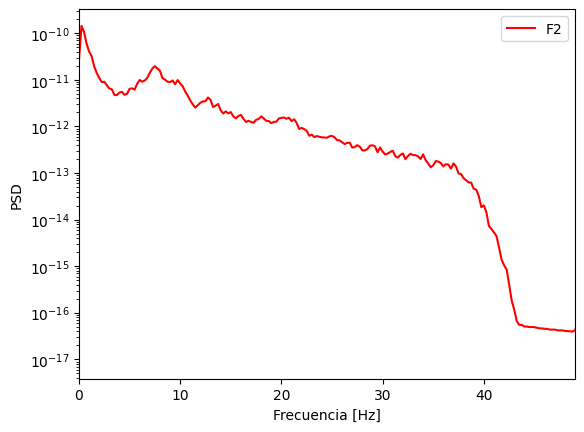

In [ ]:
import os
import gdown
from pathlib import Path
import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy
from mne.viz import plot_filter, plot_ideal_filter
import glob, os
import re
import pandas as pd
import openpyxl
from scipy.stats import spearmanr

from specparam import SpectralModel




raw = mne.io.read_raw_bdf(input_fname='../data/sub-039_task-med2_eeg.bdf', preload=True)
#eeg_channels = raw.ch_names[:64]
#Me quedo solo con los EEG
electrodos = ["F2"]
potencia=[0,0]
for i in range(len(electrodos)):
    raw_eeg=raw.copy().pick(electrodos[i]) 

    #aplicamos pasabajos con fc=100 Hz
    eeg_filtrado_2=raw_eeg.filter(l_freq=0.5, h_freq=35)

    psds, freqs = mne.time_frequency.psd_array_welch(
        eeg_filtrado_2.get_data(), 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")
    
    potencia[i]=psds[0]
    print("ELECTRODO", electrodos[i])
    #print(freqs)
    #print(psds[1])
    
plt.plot(freqs, potencia[0], color='red', label=electrodos[0])
#plt.plot(freqs, potencia[1], label=electrodos[1])
plt.semilogy()
plt.xlim(0, 49)
#plt.ylim(10e-15, 10e-9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.show()

    

  

    



Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 6759 samples (6.601 s)

Effective window size : 4.000 (s)
Effective window size : 4.000 (s)


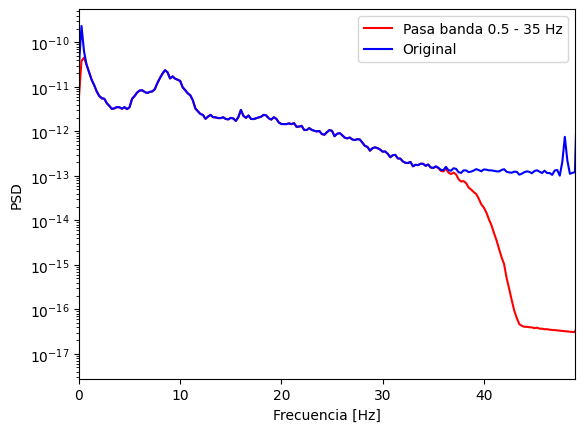

In [43]:
import mne
import matplotlib.pyplot as plt

raw = mne.io.read_raw_bdf(input_fname='../data/sub-031_task-med2_eeg.bdf', preload=True)

canal = "F2"
raw_filtrado = raw.copy().pick(canal)
raw_original = raw.copy().pick(canal)

raw_filtrado.filter(l_freq=0.5, h_freq=35)

psds_filtrado, freqs = mne.time_frequency.psd_array_welch(
    raw_filtrado.get_data(),
    sfreq=1024,
    n_fft=4096,
    fmax=100,
    n_per_seg=4096,
    output="power")

psds_original, freqs2 = mne.time_frequency.psd_array_welch(
    raw_original.get_data(),
    sfreq=1024,
    n_fft=4096,
    fmax=100,
    n_per_seg=4096,
    output="power")

plt.plot(freqs, psds_filtrado[0], color='red', label='Pasa banda 0.5 - 35 Hz')
plt.plot(freqs2, psds_original[0], color='blue', label='Original')
plt.semilogy()
plt.xlim(0, 49)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.show()

Canales comunes: 28
['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Cz', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'Fz', 'O1', 'O2', 'Oz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'Pz']
Sujetos EXP: 11, CTR: 10


/var/folders/84/36b4ykhj7dx3c82r40v03c580000gn/T/ipykernel_11045/2480711339.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


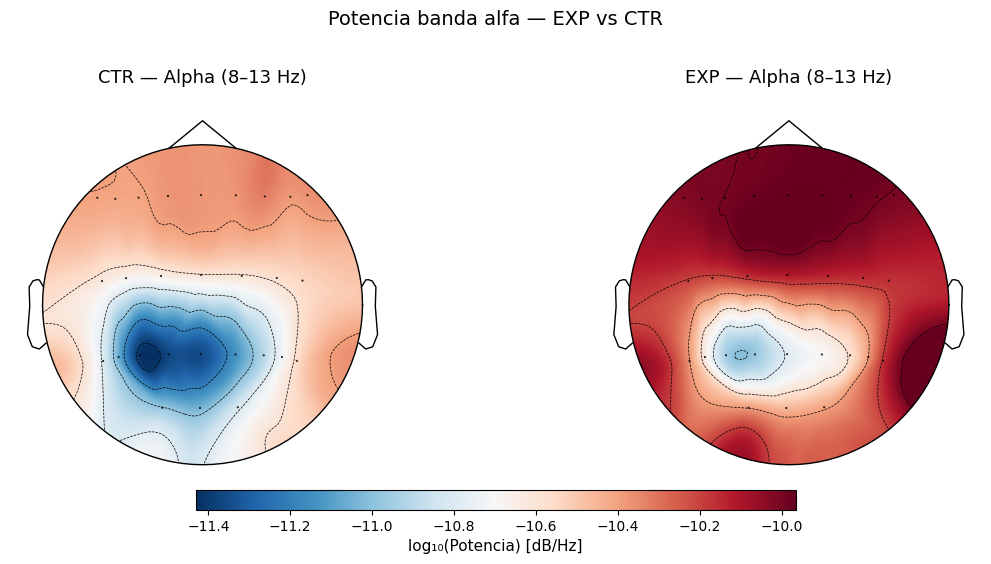

In [89]:
# Celda 1 — Imports
import mne
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

mne.set_log_level('WARNING')
# Celda 2 — Parámetros
DATA_PATH = '../data/*.bdf'
BANDAS_ALPHA = (8, 13)

def get_grupo(numero_sujeto):
    return 'EXP' if numero_sujeto >= 60 else 'CTR'

regiones = {
    "frontal": ["Fz", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8"],
    "central": ["Cz", "C1", "C2", "C3", "C4", "C5", "C6"],
    "parietal": ["Pz", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"],
    "occipital": ["Oz", "O1", "O2"],
}

# Lista completa de canales EEG usados en el análisis
canales_eeg = [canal for electrodos in regiones.values() for canal in electrodos]
# Celda 3 — Encontrar canales comunes ignorando marcas de bad
canales_eeg = [canal for electrodos in regiones.values() for canal in electrodos]
canales_por_sujeto = []

for archivo in glob.glob(DATA_PATH):
    raw = mne.io.read_raw_bdf(archivo, preload=False)
    raw.info['bads'] = []  # ignorar canales marcados como malos
    disponibles = [c for c in canales_eeg if c in raw.ch_names]
    canales_por_sujeto.append(set(disponibles))

canales_comunes = list(set.intersection(*canales_por_sujeto))
print(f"Canales comunes: {len(canales_comunes)}")
print(sorted(canales_comunes))
# Celda 4 — Calcular PSD usando TODOS los canales de la lista
canales_eeg = [canal for electrodos in regiones.values() for canal in electrodos]

alpha_por_canal = {'EXP': [], 'CTR': []}

for archivo in glob.glob(DATA_PATH):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    grupo = get_grupo(numero_sujeto)

    raw = mne.io.read_raw_bdf(archivo, preload=True)
    raw.info['bads'] = []

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    raw.filter(l_freq=0.5, h_freq=35, method='fir')
    raw.notch_filter(freqs=[16], method='fir')

    # Array de NaN para todos los canales de la lista
    potencia_sujeto = np.full(len(canales_eeg), np.nan)

    for idx, canal in enumerate(canales_eeg):
        if canal not in raw.ch_names:
            continue  # deja NaN si el canal no existe
        
        datos_canal = raw.copy().pick(canal).get_data()
        psds, freqs = mne.time_frequency.psd_array_welch(
            datos_canal,
            sfreq=raw.info['sfreq'],
            n_fft=4096,
            n_per_seg=4096,
            fmax=100,
            output='power'
        )
        mask = (freqs >= BANDAS_ALPHA[0]) & (freqs <= BANDAS_ALPHA[1])
        potencia_sujeto[idx] = np.log10(np.trapezoid(psds[0][mask], freqs[mask]))

    alpha_por_canal[grupo].append(potencia_sujeto)

mean_exp = np.nanmean(alpha_por_canal['EXP'], axis=0)
mean_ctr = np.nanmean(alpha_por_canal['CTR'], axis=0)

print(f"Sujetos EXP: {len(alpha_por_canal['EXP'])}, CTR: {len(alpha_por_canal['CTR'])}")
# Celda 5 — Topomaps
# Crear info con TODOS los canales de la lista
info = mne.create_info(ch_names=canales_eeg, sfreq=1024, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage, on_missing='ignore')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmin = min(np.nanmin(mean_exp), np.nanmin(mean_ctr))
vmax = max(np.nanmax(mean_exp), np.nanmax(mean_ctr))

mne.viz.plot_topomap(
    mean_ctr, info, axes=axes[0],
    vlim=(vmin, vmax), show=False, cmap='RdBu_r'
)
axes[0].set_title('CTR — Alpha (8–13 Hz)', fontsize=13, pad=15)

im, _ = mne.viz.plot_topomap(
    mean_exp, info, axes=axes[1],
    vlim=(vmin, vmax), show=False, cmap='RdBu_r'
)
axes[1].set_title('EXP — Alpha (8–13 Hz)', fontsize=13, pad=15)

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.04])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('log₁₀(Potencia) [dB/Hz]', fontsize=11)

plt.suptitle('Potencia banda alfa — EXP vs CTR', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('../resultados_para_analisis/topomap_alfa.png', dpi=150, bbox_inches='tight')
plt.show()